In [1]:
!git clone https://github.com/nasoskar/NLP.git
%cd NLP

Cloning into 'NLP'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 59 (delta 27), reused 48 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 275.45 KiB | 3.53 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/NLP


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.makedirs("checkpoints", exist_ok=True)

Tweets dataset already to integers:
0 -> bearish (negative)
1 -> bullish (positive)
2 -> neutral

In [4]:
import pandas as pd
import re

phrasebank_df = pd.read_csv(
    '/content/drive/MyDrive/NLP/FinancialPhraseBank-v1.0/Sentences_75Agree.txt',
    sep='@',
    header=None,
    names=['text', 'sentiment'],
    encoding='latin-1'  # needed for special characters
)

label_map = {"neutral": 2, "positive": 1, "negative": 0}
phrasebank_df['sentiment'] = phrasebank_df['sentiment'].map(label_map)

phrasebank_df.rename(columns={"sentiment": "label"}, inplace=True)

splits = {'train': 'sent_train.csv', 'validation': 'sent_valid.csv'}
df_tr = pd.read_csv("hf://datasets/zeroshot/twitter-financial-news-sentiment/" + splits["train"])
df_val = pd.read_csv("hf://datasets/zeroshot/twitter-financial-news-sentiment/" + splits["validation"])
twitter_df = pd.concat([df_tr, df_val], ignore_index=True)

total_df = pd.concat([phrasebank_df, twitter_df], ignore_index=True, sort=False)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\$[a-zA-Z]+', 'TICKER', text) # normalize tickers
    return text

pd.set_option('display.max_colwidth', None)

total_df["text"] = total_df["text"].apply(clean_text)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
# Class distribution
print(total_df["label"].value_counts(normalize=True))

# Word count stats per bucket
total_df["word_count"] = total_df["text"].str.split().str.len()
print(total_df["word_count"].describe())

# Length bucket distribution
def assign_bucket(wc):
    if wc <= 12: return "short"
    else: return "long"

total_df["bucket"] = total_df["word_count"].apply(assign_bucket)
print(total_df["bucket"].value_counts())

label
2    0.642876
1    0.213534
0    0.143591
Name: proportion, dtype: float64
count    15384.000000
mean        14.158736
std          7.700136
min          0.000000
25%          9.000000
50%         12.000000
75%         17.000000
max         81.000000
Name: word_count, dtype: float64
bucket
short    8076
long     7308
Name: count, dtype: int64


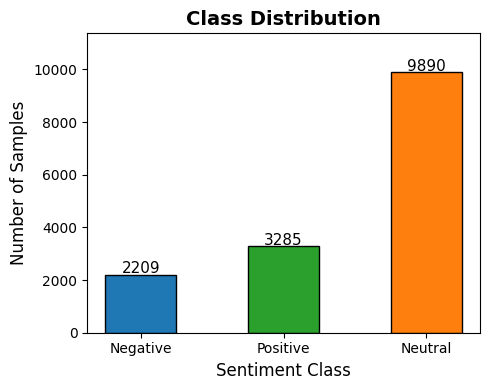

In [45]:
import matplotlib.pyplot as plt

class_counts = total_df["label"].value_counts().sort_index()
class_labels = ["Negative", "Positive", "Neutral"]
colors2= ['tab:blue', 'tab:green', 'tab:orange']

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_labels, class_counts.values, color=colors2,edgecolor="black", width=0.5)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Sentiment Class", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=11)
ax.set_ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('/classdistribution.png')
plt.show()

/tmp/ipykernel_400/4153797410.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Short (≤12)", "Long (>12)"])


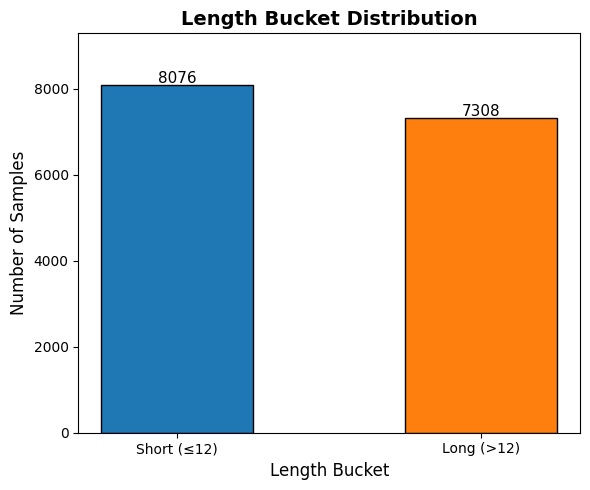

In [46]:
bucket_order = ["short", "long"]
bucket_counts = total_df["bucket"].value_counts().reindex(bucket_order)
colors2 = ['tab:blue', 'tab:orange']

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(bucket_order, bucket_counts.values, color=colors2, edgecolor="black", width=0.5)
ax.set_title("Length Bucket Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Length Bucket", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
for i, v in enumerate(bucket_counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=11)
ax.set_ylim(0, max(bucket_counts.values) * 1.15)
ax.set_xticklabels(["Short (≤12)", "Long (>12)"])
plt.tight_layout()
plt.show()

In [6]:
# See the distribution
print(total_df["word_count"].quantile([0.90, 0.95, 0.99]))

0.90    23.0
0.95    30.0
0.99    43.0
Name: word_count, dtype: float64


In [6]:
from dataset import create_dataframe, split_dataset, clean_text
from svm import SVM_Classifier

In [7]:
#Step 1: create dataframe based on the image paths
df = create_dataframe()
df['text'] = df['text'].apply(clean_text)
print(df)

                                                                                                                                                                                                                 text  \
0                                                                                     according to gran , the company has no plans to move all production to russia , although that is where the company is growing .   
1      with the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .   
2                   for the last quarter of 2010 , componenta 's net sales doubled to eur131m from eur76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of eur7m .   
3                                                                                       in the third quarter of 2010 , net sales inc

In [8]:
#Step 2: Split the dataset
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(df)


In [36]:
import pickle
#Step 3: SVM with TF-IDF
svmclass = SVM_Classifier()
svmclass.fit(X_train, y_train)

with open("/content/drive/MyDrive/NLP/checkpoints/best_svm.pkl", "wb") as f:
    pickle.dump({
        "vectorizer": svmclass.vectorizer,
        "classifier": svmclass.clf.best_estimator_,
        "best_params": svmclass.clf.best_params_,
        "best_cv_f1": round(svmclass.clf.best_score_, 3)
    }, f)

y_pred = svmclass.predict(X_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 1, 'kernel': 'rbf'}
Best macro F1: 0.7475040579054719


Heatmap for showing results of SVM fine-tuning


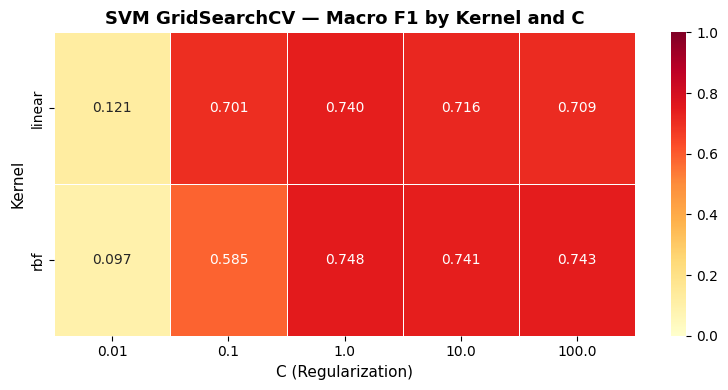

Best params: {'C': 1, 'kernel': 'rbf'}
Best CV Macro F1: 0.748


In [37]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# get results
results_df = pd.DataFrame(svmclass.clf.cv_results_)

# pivot into matrix: rows=kernel, cols=C
pivot = results_df.pivot_table(
    index="param_kernel",
    columns="param_C",
    values="mean_test_score"
)

# plot
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=1
)
ax.set_title("SVM GridSearchCV — Macro F1 by Kernel and C", fontsize=13, fontweight="bold")
ax.set_xlabel("C (Regularization)", fontsize=11)
ax.set_ylabel("Kernel", fontsize=11)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NLP/svm_gridsearch_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# print best config
print(f"Best params: {svmclass.clf.best_params_}")
print(f"Best CV Macro F1: {svmclass.clf.best_score_:.3f}")

In [38]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Overall metrics
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Macro F1:", round(f1_score(y_test, y_pred, average="macro"), 3))

# Per class breakdown
print(classification_report(y_test, y_pred, target_names=["negative", "positive", "neutral"]))

Accuracy: 0.834
Macro F1: 0.768
              precision    recall  f1-score   support

    negative       0.76      0.59      0.66       221
    positive       0.75      0.74      0.74       329
     neutral       0.87      0.92      0.90       989

    accuracy                           0.83      1539
   macro avg       0.79      0.75      0.77      1539
weighted avg       0.83      0.83      0.83      1539



In [39]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

print("=" * 50)
print("SVM — Overall Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Macro F1:  {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.3f}")
print()
print(classification_report(
    y_test, y_pred,
    target_names=["Negative", "Positive", "Neutral"]
))

# ── Per Bucket Metrics
test_buckets = total_df.loc[X_test.index, "bucket"]

print("=" * 50)
print("SVM — Results Per Length Bucket")
print("=" * 50)

bucket_results = {}
for bucket in ["short", "long"]:
    mask = test_buckets == bucket
    print(f"\n-- {bucket.upper()} (n={mask.sum()}) --")
    print(f"Accuracy:  {accuracy_score(y_test[mask], y_pred[mask]):.3f}")
    print(f"Macro F1:  {f1_score(y_test[mask], y_pred[mask], average='macro'):.3f}")
    print(f"Precision: {precision_score(y_test[mask], y_pred[mask], average='macro'):.3f}")
    print(f"Recall:    {recall_score(y_test[mask], y_pred[mask], average='macro'):.3f}")
    print(classification_report(
        y_test[mask], y_pred[mask],
        target_names=["Negative", "Positive", "Neutral"]
    ))

    # store for later comparison with LSTM and FinBERT
    bucket_results[bucket] = {
        "accuracy": round(accuracy_score(y_test[mask], y_pred[mask]), 3),
        "macro_f1": round(f1_score(y_test[mask], y_pred[mask], average="macro"), 3),
        "precision": round(precision_score(y_test[mask], y_pred[mask], average="macro"), 3),
        "recall": round(recall_score(y_test[mask], y_pred[mask], average="macro"), 3)
    }

print("\nBucket results stored:", bucket_results)

SVM — Overall Results
Accuracy:  0.834
Macro F1:  0.768
Precision: 0.794
Recall:    0.749

              precision    recall  f1-score   support

    Negative       0.76      0.59      0.66       221
    Positive       0.75      0.74      0.74       329
     Neutral       0.87      0.92      0.90       989

    accuracy                           0.83      1539
   macro avg       0.79      0.75      0.77      1539
weighted avg       0.83      0.83      0.83      1539

SVM — Results Per Length Bucket

-- SHORT (n=825) --
Accuracy:  0.847
Macro F1:  0.790
Precision: 0.807
Recall:    0.780
              precision    recall  f1-score   support

    Negative       0.78      0.62      0.69       120
    Positive       0.75      0.80      0.77       172
     Neutral       0.89      0.91      0.90       533

    accuracy                           0.85       825
   macro avg       0.81      0.78      0.79       825
weighted avg       0.85      0.85      0.85       825


-- LONG (n=714) --
Accura

Build vocabulary for LSTM

In [9]:
from dataset import build_vocab, LSTMClassification

vocab = build_vocab(X_train)

train_dataset = LSTMClassification(X_train, y_train, vocab)
val_dataset   = LSTMClassification(X_val,   y_val,   vocab)
test_dataset  = LSTMClassification(X_test,  y_test,  vocab)

Vocabulary size: 26519


In [10]:
from torch.utils.data import DataLoader
from config import *
#Step 4:  Call DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=LSTM_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=LSTM_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(train_dataloader))
input_ids = batch["input_ids"]  # shape: (32, 30)
labels    = batch["label"]      # shape: (32,)

Train LSTM

In [11]:
import torch
from train import load_glove, compute_class_weight, LSTM_train, LSTM
import numpy as np
from config import *
from lstm import *
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from itertools import product

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load glove word embeddings and class weights to handle class imbalance
glove_matrix = load_glove("/content/drive/MyDrive/NLP/glove.6B.100d.txt", vocab)
weights = compute_class_weight("balanced", classes=np.array([0,1,2]), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float)
best_f1 = 0
best_params = {}
best_train_losses = []
best_val_losses = []
best_val_f1s = []

for hidden_size, dropout, lr in product(HIDDEN_SIZES, DROPOUT_RATES, LEARNING_RATES):
    print(f"\nTrying hidden={hidden_size}, dropout={dropout}, lr={lr}")

    # Step 5: Call LSTM model
    model = LSTM(len(vocab), 100, hidden_size, 3, dropout).to(device)
    model.embedding.weight.data.copy_(glove_matrix)
    model.embedding.weight.requires_grad = True

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    val_f1, train_losses, val_losses, val_f1s = LSTM_train(
        model, optimizer, criterion, train_dataloader, val_dataloader
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_params = {"hidden_size": hidden_size, "dropout": dropout, "lr": lr}

        # update losses only when new best found
        best_train_losses = train_losses
        best_val_losses = val_losses
        best_val_f1s = val_f1s

        torch.save({
            "model_state_dict": model.state_dict(),
            "params": best_params,
            "vocab_size": len(vocab),
            "embedding_dim": 100,
            "out_features": 3,
            "val_f1": round(best_f1, 4)
        }, "/content/drive/MyDrive/NLP/checkpoints/best_lstm.pth")

print(f"\nBest params: {best_params}")
print(f"Best val F1: {best_f1:.4f}")


Trying hidden=64, dropout=0.3, lr=0.001
Epoch 1/20 | Train Loss: 1.0160 | Val Loss: 0.9159 | Val Macro F1: 0.4317
Epoch 2/20 | Train Loss: 0.8041 | Val Loss: 0.8246 | Val Macro F1: 0.4535
Epoch 3/20 | Train Loss: 0.6643 | Val Loss: 0.8592 | Val Macro F1: 0.5587
Epoch 4/20 | Train Loss: 0.5273 | Val Loss: 0.8235 | Val Macro F1: 0.6832
Epoch 5/20 | Train Loss: 0.3010 | Val Loss: 0.7165 | Val Macro F1: 0.6976
Epoch 6/20 | Train Loss: 0.1839 | Val Loss: 1.0084 | Val Macro F1: 0.7102
Epoch 7/20 | Train Loss: 0.1092 | Val Loss: 1.0293 | Val Macro F1: 0.6896
Epoch 8/20 | Train Loss: 0.0863 | Val Loss: 1.0731 | Val Macro F1: 0.7183
Epoch 9/20 | Train Loss: 0.0625 | Val Loss: 1.2249 | Val Macro F1: 0.7007
Early stopping at epoch 9

Trying hidden=64, dropout=0.3, lr=0.0001
Epoch 1/20 | Train Loss: 1.0961 | Val Loss: 1.0941 | Val Macro F1: 0.3152
Epoch 2/20 | Train Loss: 1.0932 | Val Loss: 1.0912 | Val Macro F1: 0.3202
Epoch 3/20 | Train Loss: 1.0619 | Val Loss: 1.0004 | Val Macro F1: 0.4645
Epo

output the loss curves of LSTM with best params

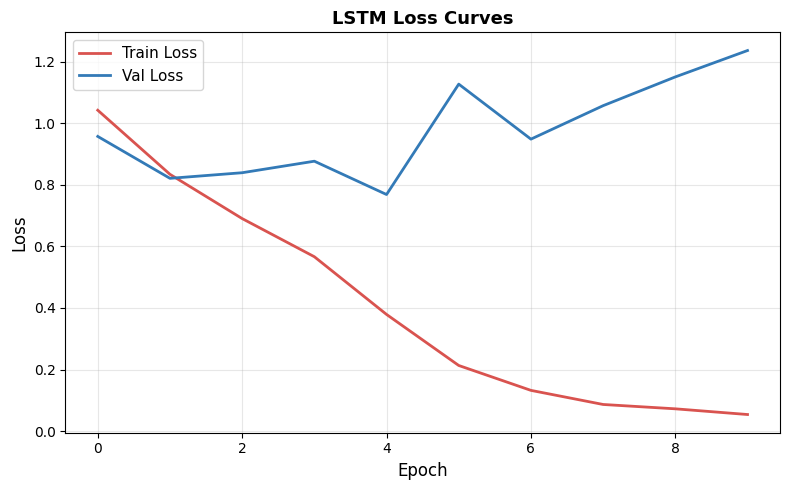

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(best_train_losses, label="Train Loss", color="#d9534f", linewidth=2)
ax.plot(best_val_losses, label="Val Loss", color="#337ab7", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("LSTM Loss Curves", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NLP/lstm_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Evaluate on LSTM test set and get all metrics

LSTM — Overall Results
Accuracy:  0.782
Macro F1:  0.729
Precision: 0.728
Recall:    0.747

              precision    recall  f1-score   support

    Negative       0.70      0.64      0.67       221
    Positive       0.56      0.79      0.66       329
     Neutral       0.92      0.81      0.86       989

    accuracy                           0.78      1539
   macro avg       0.73      0.75      0.73      1539
weighted avg       0.81      0.78      0.79      1539

LSTM — Results Per Length Bucket

-- SHORT (n=825) --
              precision    recall  f1-score   support

    Negative       0.70      0.67      0.68       120
    Positive       0.58      0.84      0.69       172
     Neutral       0.93      0.80      0.86       533

    accuracy                           0.79       825
   macro avg       0.73      0.77      0.74       825
weighted avg       0.82      0.79      0.80       825


-- MEDIUM — no samples --

-- LONG (n=714) --
              precision    recall  f1-score  

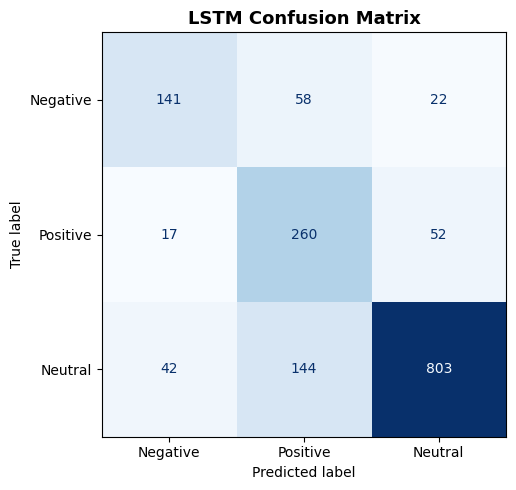

In [18]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

test_dataset = LSTMClassification(X_test, y_test, vocab)
test_dataloader = DataLoader(test_dataset, batch_size=LSTM_BATCH_SIZE, shuffle=False)

checkpoint = torch.load("/content/drive/MyDrive/NLP/checkpoints/best_lstm.pth")
model = LSTM(
    vocab_size=checkpoint["vocab_size"],
    embedding_dim=checkpoint["embedding_dim"],
    hidden_size=checkpoint["params"]["hidden_size"],
    out_features=checkpoint["out_features"],
    dropout=checkpoint["params"]["dropout"]
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        inputs = batch["input_ids"].to(device)
        labels = batch["label"].to(device)
        output = model(inputs)
        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("=" * 50)
print("LSTM — Overall Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.3f}")
print(f"Macro F1:  {f1_score(all_labels, all_preds, average='macro'):.3f}")
print(f"Precision: {precision_score(all_labels, all_preds, average='macro'):.3f}")
print(f"Recall:    {recall_score(all_labels, all_preds, average='macro'):.3f}")
print()
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive", "Neutral"]))

# ── 5. Per Bucket Metrics ─────────────────────────────────────────────────────
test_buckets = total_df.loc[X_test.index, "bucket"]

print("=" * 50)
print("LSTM — Results Per Length Bucket")
print("=" * 50)

lstm_bucket_results = {}
for bucket in ["short", "medium", "long"]:
    mask = test_buckets == bucket

    if mask.sum() == 0:
        print(f"\n-- {bucket.upper()} — no samples --")
        continue

    y_true_bucket = [all_labels[i] for i, m in enumerate(mask) if m]
    y_pred_bucket = [all_preds[i] for i, m in enumerate(mask) if m]

    print(f"\n-- {bucket.upper()} (n={mask.sum()}) --")
    print(classification_report(
        y_true_bucket,
        y_pred_bucket,
        target_names=["Negative", "Positive", "Neutral"],
        labels=[0, 1, 2],
        zero_division=0
    ))

    lstm_bucket_results[bucket] = {
        "accuracy": round(accuracy_score(y_true_bucket, y_pred_bucket), 3),
        "macro_f1": round(f1_score(y_true_bucket, y_pred_bucket, average="macro", zero_division=0), 3),
        "precision": round(precision_score(y_true_bucket, y_pred_bucket, average="macro", zero_division=0), 3),
        "recall": round(recall_score(y_true_bucket, y_pred_bucket, average="macro", zero_division=0), 3)
    }

print("\nBucket results:", lstm_bucket_results)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive", "Neutral"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("LSTM Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NLP/lstm_confusion_matrix.png", dpi=150)
plt.show()

In [51]:
import time

# run this while training
for i in range(1000):
    time.sleep(60)
    print(f"Alive: {i} minutes")

Alive: 0 minutes
Alive: 1 minutes
Alive: 2 minutes
Alive: 3 minutes
Alive: 4 minutes
Alive: 5 minutes
Alive: 6 minutes
Alive: 7 minutes
Alive: 8 minutes
Alive: 9 minutes
Alive: 10 minutes
Alive: 11 minutes
Alive: 12 minutes
Alive: 13 minutes
Alive: 14 minutes
Alive: 15 minutes
Alive: 16 minutes
Alive: 17 minutes
Alive: 18 minutes
Alive: 19 minutes
Alive: 20 minutes
Alive: 21 minutes
Alive: 22 minutes
Alive: 23 minutes
Alive: 24 minutes
Alive: 25 minutes
Alive: 26 minutes
Alive: 27 minutes
Alive: 28 minutes
Alive: 29 minutes
Alive: 30 minutes
Alive: 31 minutes
Alive: 32 minutes
Alive: 33 minutes
Alive: 34 minutes
Alive: 35 minutes
Alive: 36 minutes
Alive: 37 minutes
Alive: 38 minutes
Alive: 39 minutes
Alive: 40 minutes
Alive: 41 minutes
Alive: 42 minutes
Alive: 43 minutes
Alive: 44 minutes
Alive: 45 minutes
Alive: 46 minutes
Alive: 47 minutes
Alive: 48 minutes
Alive: 49 minutes
Alive: 50 minutes
Alive: 51 minutes
Alive: 52 minutes
Alive: 53 minutes
Alive: 54 minutes
Alive: 55 minutes
Al

KeyboardInterrupt: 

FINBERT

In [20]:
def finbert_train(model, optimizer, criterion, train_dataloader, val_dataloader):
    best_val_loss = float('inf')
    best_val_f1 = 0
    patience_counter = 0
    min_delta = 0.005

    train_losses = []
    val_losses = []
    val_f1s = []

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.

        for data in train_dataloader:
            input_ids = data["input_ids"].to(device)
            attention_mask = data["attention_mask"].to(device)
            labels = data["label"].to(device)

            optimizer.zero_grad()
            output = model(input_ids, attention_mask)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_dataloader))
        model.eval()
        val_loss = 0.
        all_preds = []
        all_labels= []

        with torch.no_grad():
            for data in val_dataloader:
                input_ids = data["input_ids"].to(device)
                attention_mask = data["attention_mask"].to(device)
                labels = data["label"].to(device)

                output = model(input_ids, attention_mask)
                loss = criterion(output, labels)
                val_loss += loss.item()

                preds = torch.argmax(output, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_losses.append(val_loss / len(val_dataloader))
        val_f1 = f1_score(all_labels, all_preds, average="macro")
        val_f1s.append(val_f1)

        if val_loss < best_val_loss - min_delta:
            patience_counter = 0
            best_val_loss =  val_loss
            best_val_f1 = val_f1
            torch.save(model.state_dict(), "checkpoints/best_finbert.pth")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {running_loss/len(train_dataloader):.4f} | Val Loss: {val_loss/len(val_dataloader):.4f} | Val Macro F1: {val_f1:.4f}")

    return best_val_f1, train_losses, val_losses, val_f1s

In [22]:
import torch
from finbert import FINBERT
#from train import finbert_train
from dataset import FinBertDataset
from config import *
from lstm import *
from itertools import product


train_dataset_bert = FinBertDataset(X_train, y_train)
val_dataset_bert   = FinBertDataset(X_val,   y_val)
test_dataset_bert  = FinBertDataset(X_test,  y_test)
#Step 4:  Call DataLoader
train_dataloader_bert = DataLoader(train_dataset_bert, batch_size=FINBERT_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_dataloader_bert = DataLoader(val_dataset_bert, batch_size=FINBERT_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dataloader  = DataLoader(test_dataset_bert,  batch_size=FINBERT_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(train_dataloader_bert))
input_ids = batch["input_ids"]  # shape: (32, 30)
labels    = batch["label"]      # shape: (32,)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_f1 = 0
best_params = {}
best_train_losses = []
best_val_losses = []
best_val_f1s = []
finbert_results = []

for dropout, lr in product(FINBERT_DROPOUTS, FINBERT_LRS):
    print(f"\nTrying dropout={dropout}, lr={lr}")

    # Step 5: Call FINBERT model
    model = FINBERT(dropout).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    val_f1, train_losses, val_losses, val_f1s = finbert_train(
        model, optimizer, criterion, train_dataloader_bert, val_dataloader_bert
    )

    finbert_results.append({
        "dropout": dropout,
        "lr": lr,
        "val_f1": round(val_f1, 4)
    })

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_params = {"dropout": dropout, "lr": lr}
        best_train_losses = train_losses
        best_val_losses = val_losses
        best_val_f1s = val_f1s
        torch.save(model.state_dict(), "/content/drive/MyDrive/NLP/checkpoints/best_finbert_overall.pth")

print(f"\nBest params: {best_params}")
print(f"Best val F1: {best_f1:.4f}")


Trying dropout=0.1, lr=2e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/20 | Train Loss: 0.4437 | Val Loss: 0.2963 | Val Macro F1: 0.8368
Epoch 2/20 | Train Loss: 0.2210 | Val Loss: 0.2775 | Val Macro F1: 0.8481
Epoch 3/20 | Train Loss: 0.1123 | Val Loss: 0.3316 | Val Macro F1: 0.8527
Epoch 4/20 | Train Loss: 0.0771 | Val Loss: 0.3577 | Val Macro F1: 0.8677
Epoch 5/20 | Train Loss: 0.0525 | Val Loss: 0.4651 | Val Macro F1: 0.8726
Epoch 6/20 | Train Loss: 0.0421 | Val Loss: 0.5026 | Val Macro F1: 0.8850
Early stopping at epoch 7

Trying dropout=0.1, lr=3e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/20 | Train Loss: 0.4537 | Val Loss: 0.2797 | Val Macro F1: 0.8469
Epoch 2/20 | Train Loss: 0.2258 | Val Loss: 0.2866 | Val Macro F1: 0.8510
Epoch 3/20 | Train Loss: 0.1236 | Val Loss: 0.3333 | Val Macro F1: 0.8758
Epoch 4/20 | Train Loss: 0.0723 | Val Loss: 0.4085 | Val Macro F1: 0.8712
Epoch 5/20 | Train Loss: 0.0544 | Val Loss: 0.4615 | Val Macro F1: 0.8740
Early stopping at epoch 6

Trying dropout=0.3, lr=3e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/20 | Train Loss: 0.4505 | Val Loss: 0.3025 | Val Macro F1: 0.8313
Epoch 2/20 | Train Loss: 0.2124 | Val Loss: 0.3132 | Val Macro F1: 0.8522
Epoch 3/20 | Train Loss: 0.1261 | Val Loss: 0.3399 | Val Macro F1: 0.8694
Epoch 4/20 | Train Loss: 0.0813 | Val Loss: 0.3706 | Val Macro F1: 0.8798
Epoch 5/20 | Train Loss: 0.0579 | Val Loss: 0.4893 | Val Macro F1: 0.8820
Early stopping at epoch 6

Best params: {'dropout': 0.1, 'lr': 3e-05}
Best val F1: 0.8609


In [24]:
print(finbert_results)

[{'dropout': 0.1, 'lr': 2e-05, 'val_f1': 0.8481}, {'dropout': 0.1, 'lr': 3e-05, 'val_f1': 0.8609}, {'dropout': 0.3, 'lr': 2e-05, 'val_f1': 0.8469}, {'dropout': 0.3, 'lr': 3e-05, 'val_f1': 0.8313}]


In [ ]:
torch.load()

Heatmap of configurations

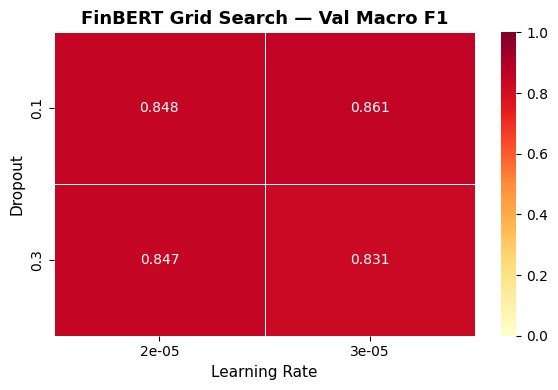

In [25]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(finbert_results)
pivot = results_df.pivot(index="dropout", columns="lr", values="val_f1")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=1
)
ax.set_title("FinBERT Grid Search — Val Macro F1", fontsize=13, fontweight="bold")
ax.set_xlabel("Learning Rate", fontsize=11)
ax.set_ylabel("Dropout", fontsize=11)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NLP/finbert_gridsearch_heatmap.png", dpi=150)
plt.show()

Loss curves of best finbert model

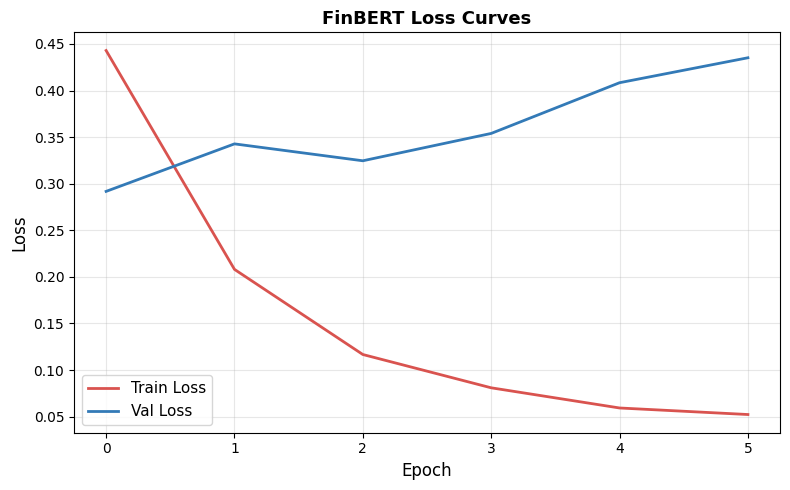

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(best_train_losses, label="Train Loss", color="#d9534f", linewidth=2)
ax.plot(best_val_losses, label="Val Loss", color="#337ab7", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("FinBERT Loss Curves", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NLP/finbert_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

evaluation metrics and confusion matrix

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully
Best params: {'dropout': 0.1, 'lr': 3e-05}
FinBERT — Overall Results
Accuracy:  0.843
Macro F1:  0.819
Precision: 0.789
Recall:    0.872

              precision    recall  f1-score   support

    Negative       0.71      0.88      0.78       221
    Positive       0.69      0.93      0.79       329
     Neutral       0.97      0.80      0.88       989

    accuracy                           0.84      1539
   macro avg       0.79      0.87      0.82      1539
weighted avg       0.87      0.84      0.85      1539

FinBERT — Results Per Length Bucket

-- SHORT (n=825) --
              precision    recall  f1-score   support

    Negative       0.65      0.88      0.75       120
    Positive       0.71      0.92      0.81       172
     Neutral       0.97      0.80      0.88       533

    accuracy                           0.84       825
   macro avg       0.78      0.87      0.81       825
weighted avg       0.87      0.84      0.85       825


-- LONG (n=714) 

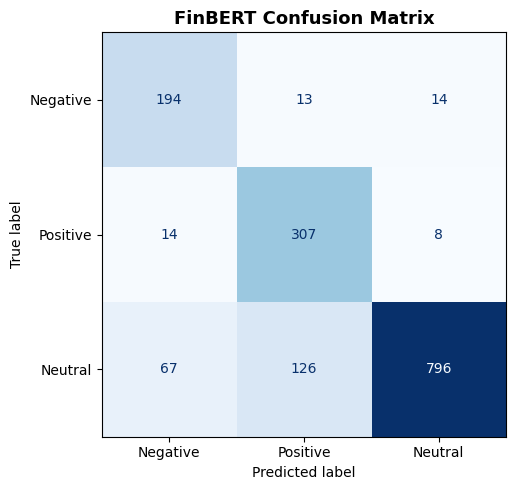

In [33]:
# load checkpoint
checkpoint = torch.load("/content/drive/MyDrive/NLP/checkpoints/best_finbert_overall.pth")
# use best_params from grid search
model = FINBERT(dropout=best_params["dropout"]).to(device)
model.load_state_dict(checkpoint)
model.eval()
print("Model loaded successfully")
print("Best params:", best_params)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
        output = model(input_ids, attention_mask)
        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("=" * 50)
print("FinBERT — Overall Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.3f}")
print(f"Macro F1:  {f1_score(all_labels, all_preds, average='macro'):.3f}")
print(f"Precision: {precision_score(all_labels, all_preds, average='macro'):.3f}")
print(f"Recall:    {recall_score(all_labels, all_preds, average='macro'):.3f}")
print()
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive", "Neutral"]))

test_buckets = total_df.loc[X_test.index, "bucket"]

print("=" * 50)
print("FinBERT — Results Per Length Bucket")
print("=" * 50)

finbert_bucket_results = {}
for bucket in ["short", "long"]:
    mask = test_buckets == bucket

    if mask.sum() == 0:
        print(f"\n-- {bucket.upper()} — no samples --")
        continue

    y_true_bucket = [all_labels[i] for i, m in enumerate(mask) if m]
    y_pred_bucket = [all_preds[i] for i, m in enumerate(mask) if m]

    print(f"\n-- {bucket.upper()} (n={mask.sum()}) --")
    print(classification_report(
        y_true_bucket, y_pred_bucket,
        target_names=["Negative", "Positive", "Neutral"],
        labels=[0, 1, 2],
        zero_division=0
    ))

    finbert_bucket_results[bucket] = {
        "accuracy": round(accuracy_score(y_true_bucket, y_pred_bucket), 3),
        "macro_f1": round(f1_score(y_true_bucket, y_pred_bucket, average="macro", zero_division=0), 3),
        "precision": round(precision_score(y_true_bucket, y_pred_bucket, average="macro", zero_division=0), 3),
        "recall": round(recall_score(y_true_bucket, y_pred_bucket, average="macro", zero_division=0), 3)
    }

print("\nBucket results:", finbert_bucket_results)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive", "Neutral"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("FinBERT Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NLP/finbert_confusion_matrix.png", dpi=150)
plt.show()

Get plots to compare all 3 models

In [45]:
svm_overall = {
    "accuracy":  0.834,
    "precision": 0.768,
    "recall":    0.794,
    "macro_f1":  0.749
}

lstm_overall = {
    "accuracy":  0.782,
    "precision": 0.728,
    "recall":    0.747,
    "macro_f1":  0.729
}

finbert_overall = {
    "accuracy":  0.843,
    "precision": 0.819,
    "recall":    0.789,
    "macro_f1":  0.872
}

In [46]:
print("=" * 65)
print(f"{'Model':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'Macro F1':>10}")
print("=" * 65)
print(f"{'SVM':<12} {svm_overall['accuracy']:>10.3f} {svm_overall['precision']:>10.3f} {svm_overall['recall']:>10.3f} {svm_overall['macro_f1']:>10.3f}")
print(f"{'LSTM':<12} {lstm_overall['accuracy']:>10.3f} {lstm_overall['precision']:>10.3f} {lstm_overall['recall']:>10.3f} {lstm_overall['macro_f1']:>10.3f}")
print(f"{'FinBERT':<12} {finbert_overall['accuracy']:>10.3f} {finbert_overall['precision']:>10.3f} {finbert_overall['recall']:>10.3f} {finbert_overall['macro_f1']:>10.3f}")
print("=" * 65)

Model          Accuracy  Precision     Recall   Macro F1
SVM               0.834      0.768      0.794      0.749
LSTM              0.782      0.728      0.747      0.729
FinBERT           0.843      0.819      0.789      0.872


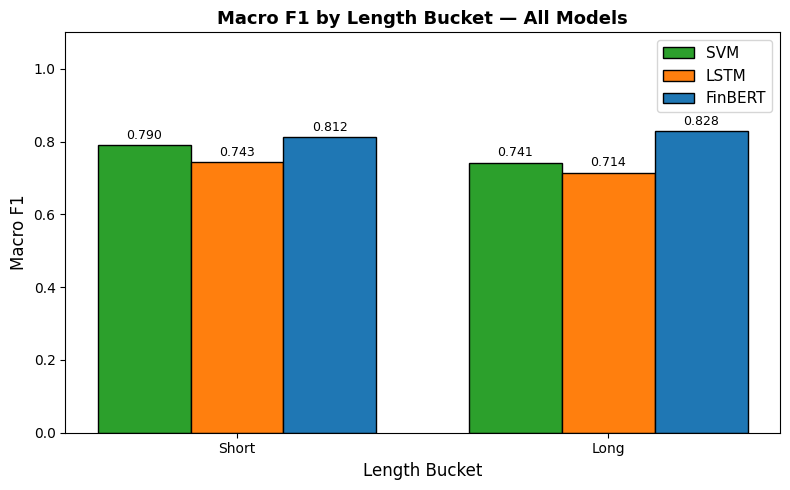

In [50]:
buckets = ["Short", "Long"]

svm_f1     = [bucket_results["short"]["macro_f1"],     bucket_results["long"]["macro_f1"]]
lstm_f1    = [lstm_bucket_results["short"]["macro_f1"],    lstm_bucket_results["long"]["macro_f1"]]
finbert_f1 = [finbert_bucket_results["short"]["macro_f1"], finbert_bucket_results["long"]["macro_f1"]]

x = np.arange(len(buckets))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, svm_f1,     width, label="SVM",     color="tab:green", edgecolor="black")
bars2 = ax.bar(x,         lstm_f1,    width, label="LSTM",    color="tab:orange", edgecolor="black")
bars3 = ax.bar(x + width, finbert_f1, width, label="FinBERT", color="tab:blue", edgecolor="black")

for bar in [bars1, bars2, bars3]:
    for rect in bar:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Length Bucket", fontsize=12)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Macro F1 by Length Bucket — All Models", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(buckets)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)


plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NLP/final_bucket_comparison.png", dpi=150)
plt.show()

In [52]:
import pandas as pd

# get test texts
test_texts = total_df.loc[X_test.index, "text"].reset_index(drop=True)
test_buckets = total_df.loc[X_test.index, "bucket"].reset_index(drop=True)

# convert to arrays
y_true = list(y_test)
y_pred_finbert = list(all_preds)  # use your best model (FinBERT)

label_map = {0: "Negative", 1: "Positive", 2: "Neutral"}

# build dataframe of all test samples
error_df = pd.DataFrame({
    "text": test_texts.values,
    "true_label": [label_map[l] for l in y_true],
    "pred_label": [label_map[p] for p in y_pred_finbert],
    "bucket": test_buckets.values
})

# filter only misclassified
errors = error_df[error_df["true_label"] != error_df["pred_label"]].reset_index(drop=True)
print(f"Total errors: {len(errors)}")
print(errors["true_label"].value_counts())

Total errors: 242
true_label
Neutral     193
Negative     27
Positive     22
Name: count, dtype: int64


In [54]:
# sample 40 errors — stratified by true label
sample = errors.groupby("true_label").apply(
    lambda x: x.sample(min(len(x), 13), random_state=42)
).reset_index(drop=True)

print(f"Sampled {len(sample)} errors")
print(sample[["text", "true_label", "pred_label", "bucket"]])

sample.to_csv("/content/drive/MyDrive/NLP/error_analysis.csv", index=False)
print("Saved to Drive")

Sampled 39 errors
                                                                                                                                                                                                                           text  \
0                                                                                                                                                     china iron ore surges to over 4-month high as supply uncertainties loom     
1                                                                                                                                    spanish farmers rise up against unfair prices amidst the worst agri-food crisis in decades   
2   adp news - apr 22 , 2009 - finnish business information systems developer solteq oyj hel : stq1v said today its net loss widened to eur 189,000 usd 245,000 for the first quarter of 2009 from eur 10,000 for the same peri   
3                                                                         

/tmp/ipykernel_2340/1569421186.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = errors.groupby("true_label").apply(


In [58]:
import pandas as pd
error = pd.read_csv('/content/drive/MyDrive/NLP/error_analysis.csv')
error

,text,true_label,pred_label,bucket
0,china iron ore surges to over 4-month high as supply uncertainties loom,Negative,Positive,short
1,spanish farmers rise up against unfair prices amidst the worst agri-food crisis in decades,Negative,Positive,long
2,"adp news - apr 22 , 2009 - finnish business information systems developer solteq oyj hel : stq1v said today its net loss widened to eur 189,000 usd 245,000 for the first quarter of 2009 from eur 10,000 for the same peri",Negative,Positive,long
3,TICKER: nonfarm payroll revisions- october revised to 135k from 189k; september revised to 193k from 180k,Negative,Positive,long
4,why aurora cannabis is getting hammered today,Negative,Positive,short
5,TICKER: garrett motion withdraws fy 20 guidance,Negative,Neutral,short
6,"the dual shocks of the saudi-russian oil price war and the covid-19 pandemic could put 500,000 albertans out of wor…",Negative,Positive,long
7,the federal reserve's rescue of the overnight lending market appears to be having an unintended side effect: it's j…,Negative,Neutral,long
8,recap 12/10 unusual puts:\nTICKER jan 6 p\nTICKER jan 240 p\nTICKER dec 123 p\nTICKER jan 31 p\nTICKER dec 26 p\nTICKER apr 35 p…,Negative,Positive,long
9,coronavirus task force declares public health emergency,Negative,Neutral,short
